<a href="https://colab.research.google.com/github/LavanyaMaruthachalam/HTMLActorPage/blob/main/Acoustic_Bowl_Movements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Upload your files to Colab (zip or csv + wavs)

In [ ]:
from google.colab import files
import zipfile, os, glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
from IPython.display import Audio, display
import soundfile as sf
from scipy import signal, stats


uploaded = files.upload()  # choose your zip or csv/wavs
print("Uploaded:", list(uploaded.keys()))


Saving dataset_v2_filtered.zip to dataset_v2_filtered.zip
Uploaded: ['dataset_v2_filtered.zip']


2)Uploaded a ZIP, unzip it

In [ ]:
# Find the first uploaded zip
zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if zip_files:
    zip_path = zip_files[0]
    print("Unzipping:", zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("data")
    print("Extracted to: data/")
else:
    print("No zip uploaded. If you uploaded csv/wavs directly, skip this step.")


Unzipping: dataset_v2_filtered.zip
Extracted to: data/


3) Locate and load dataset_metadata.csv

In [ ]:
# Search for the metadata file
candidates = glob.glob("**/dataset_metadata.csv", recursive=True)
print("Found metadata files:", candidates)

if not candidates:
    raise FileNotFoundError("dataset_metadata.csv not found. Upload it or unzip the correct folder.")

meta_path = candidates[0]
df = pd.read_csv(meta_path)
print("Using:", meta_path)
df


Found metadata files: ['data/dataset_metadata.csv']
Using: data/dataset_metadata.csv


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav
...,...,...,...,...,...,...,...,...,...,...
7107,11_23_0119_chunk_003.wav,11,2025-11-23 01:19:00,3,NaN,139.0,184.0,764.0,0.17,11_23_0119.wav
7108,11_23_0119_chunk_004.wav,11,2025-11-23 01:19:00,4,NaN,139.0,184.0,764.0,0.16,11_23_0119.wav
7109,11_23_0119_chunk_005.wav,11,2025-11-23 01:19:00,5,NaN,139.0,184.0,764.0,0.17,11_23_0119.wav
7110,11_23_0119_chunk_006.wav,11,2025-11-23 01:19:00,6,NaN,139.0,184.0,764.0,0.15,11_23_0119.wav


4) Basic metadata inspection + quick plots

Shape: (7112, 10)

Columns:
 ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file']

Missing values (%):
 filename                          0.00
session_id                        0.00
datetime                          0.00
chunk_index                       0.00
minutes_until_defecation          0.45
minutes_since_last_defecation    11.64
minutes_since_meal                0.90
minutes_since_wake                0.00
duration                          0.00
original_file                     0.00
dtype: float64


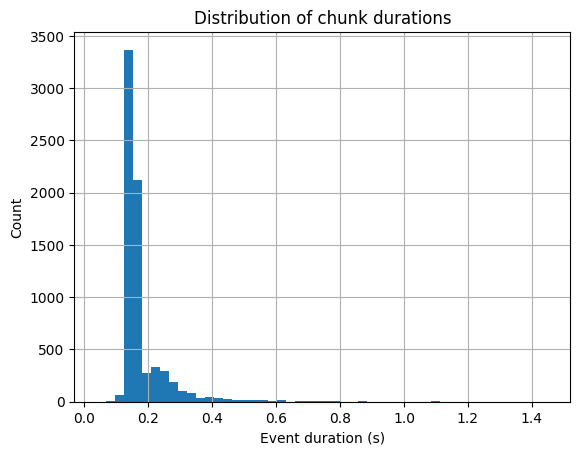

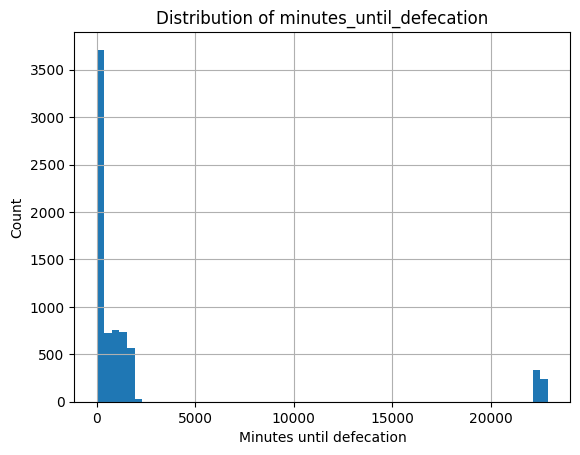

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values (%):\n", (df.isna().mean()*100).round(2))

# Duration distribution
plt.figure()
df["duration"].dropna().hist(bins=50)
plt.xlabel("Event duration (s)")
plt.ylabel("Count")
plt.title("Distribution of chunk durations")
plt.show()

# minutes_until_defecation distribution (ignore NaNs)
plt.figure()
df["minutes_until_defecation"].dropna().hist(bins=60)
plt.xlabel("Minutes until defecation")
plt.ylabel("Count")
plt.title("Distribution of minutes_until_defecation")
plt.show()


5) Time-to-defecation vs duration (scatter)

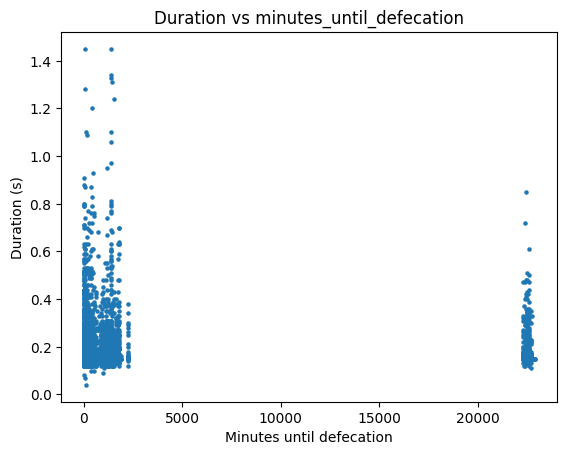

In [ ]:
plt.figure()
tmp = df.dropna(subset=["minutes_until_defecation", "duration"])
plt.scatter(tmp["minutes_until_defecation"], tmp["duration"], s=5)
plt.xlabel("Minutes until defecation")
plt.ylabel("Duration (s)")
plt.title("Duration vs minutes_until_defecation")
plt.show()


6) Load and visualize a few WAV chunks (waveform + spectrogram + playback)

This will:

find the chunks/ folder

pick a few chunks nearest to defecation (small minutes) if available

plot waveform + spectrogram

allow playback in Colab

Found chunks folders: ['data/chunks']
Using chunks dir: data/chunks

File: 10_29_1614_chunk_005.wav | sr=8000 | duration=0.34s | minutes_until_defecation=6.0


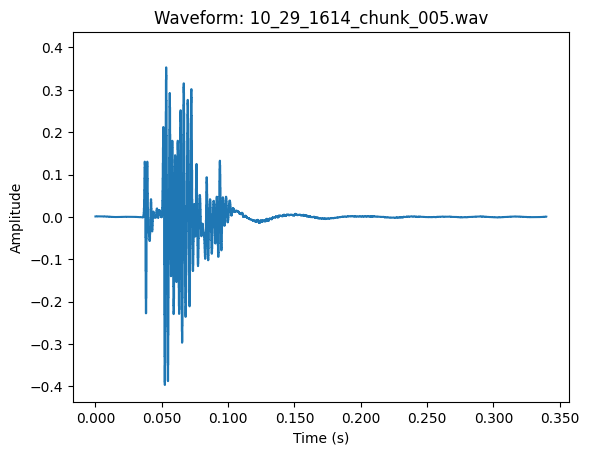

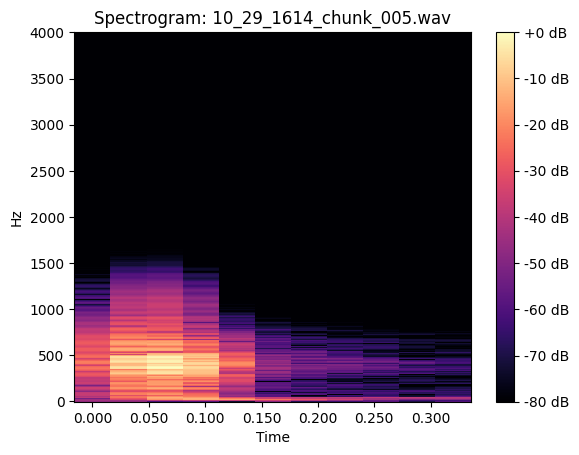


File: 10_29_1614_chunk_004.wav | sr=8000 | duration=0.16s | minutes_until_defecation=6.0


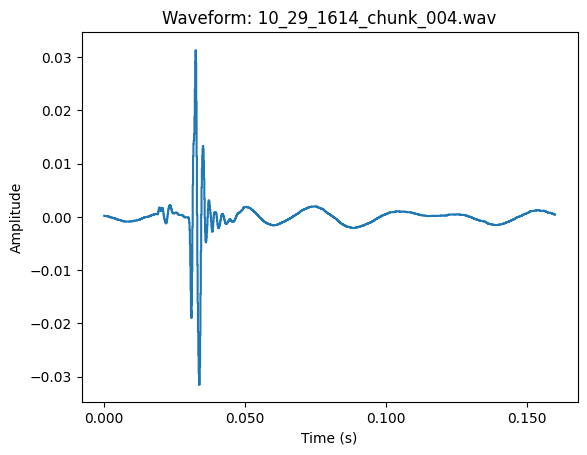

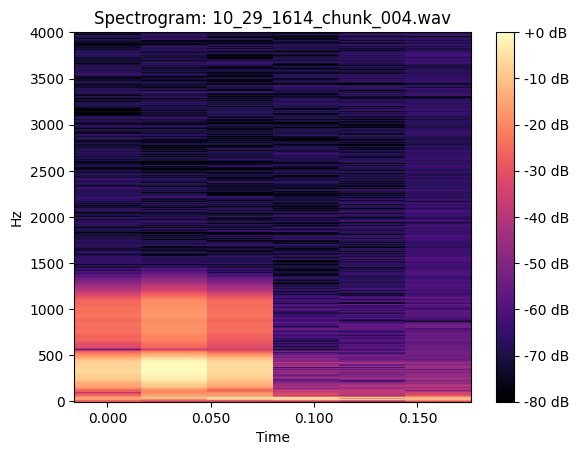


File: 10_29_1614_chunk_003.wav | sr=8000 | duration=0.16s | minutes_until_defecation=6.0


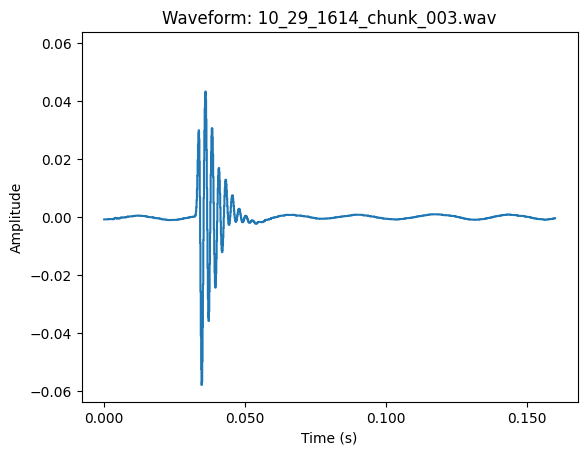

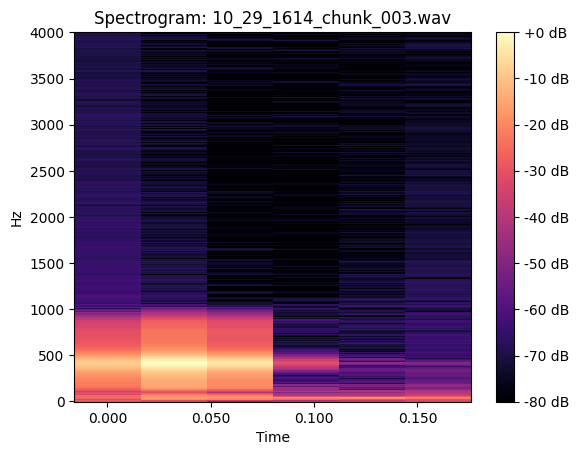


File: 10_29_1614_chunk_002.wav | sr=8000 | duration=0.16s | minutes_until_defecation=6.0


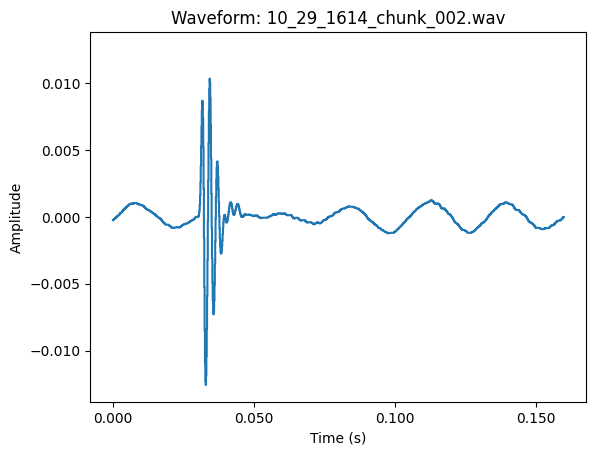

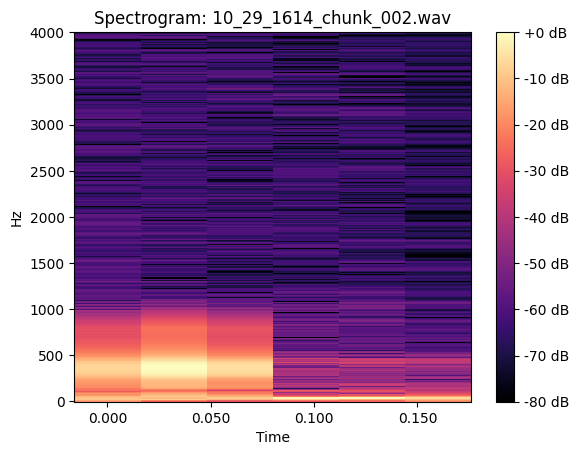


File: 10_29_1614_chunk_001.wav | sr=8000 | duration=0.17s | minutes_until_defecation=6.0


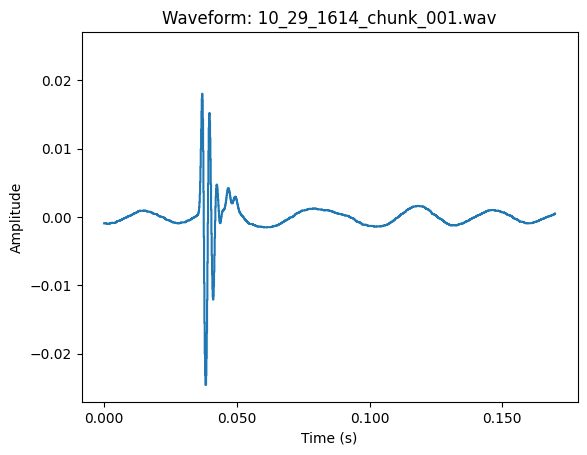

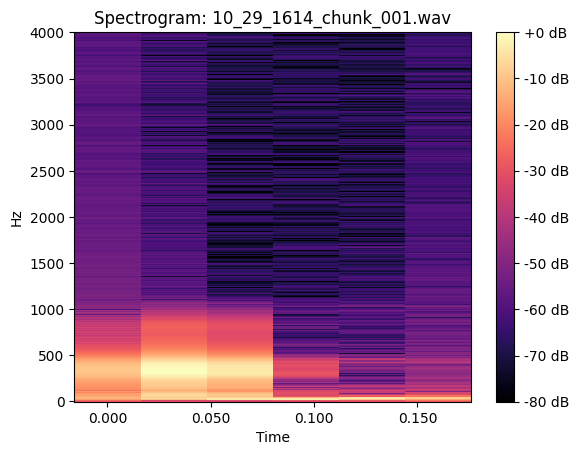

In [ ]:
# Find chunks folder
chunks_dirs = [p for p in glob.glob("**/chunks", recursive=True) if os.path.isdir(p)]
print("Found chunks folders:", chunks_dirs)

if not chunks_dirs:
    print("No chunks/ folder found. Upload wav files or unzip dataset folder containing chunks/")
else:
    chunks_dir = chunks_dirs[0]
    print("Using chunks dir:", chunks_dir)

    # Choose 5 samples: closest to defecation if label exists, else random
    if "minutes_until_defecation" in df.columns and df["minutes_until_defecation"].notna().any():
        sample_df = df.dropna(subset=["minutes_until_defecation"]).sort_values("minutes_until_defecation").head(5)
    else:
        sample_df = df.sample(10, random_state=42)

    for i, row in sample_df.iterrows():
        wav_path = os.path.join(chunks_dir, row["filename"])
        if not os.path.exists(wav_path):
            print("Missing wav:", wav_path)
            continue

        y, sr = librosa.load(wav_path, sr=None, mono=True)

        print(f"\nFile: {row['filename']} | sr={sr} | duration={len(y)/sr:.2f}s | minutes_until_defecation={row.get('minutes_until_defecation', None)}")

        # Waveform
        plt.figure()
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform: {row['filename']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

        # Spectrogram (dB)
        S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        plt.figure()
        librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram: {row['filename']}")
        plt.show()

        # Playback
        display(Audio(y, rate=sr))


/tmp/ipython-input-1991005119.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = tmp["filename"].resample("1H").count()


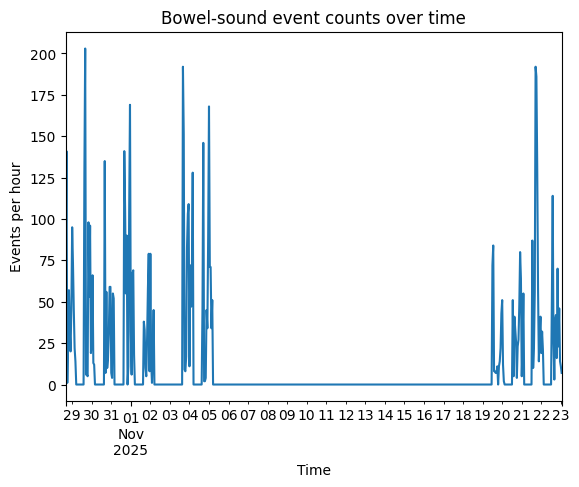

In [ ]:
# Convert datetime string to pandas datetime (your format looks like YYYY-MM-DD HH:mm:00)
df["datetime_parsed"] = pd.to_datetime(df["datetime"], errors="coerce")

# Count events per hour (or per 30 minutes)
tmp = df.dropna(subset=["datetime_parsed"]).set_index("datetime_parsed")
counts = tmp["filename"].resample("1H").count()

plt.figure()
counts.plot()
plt.xlabel("Time")
plt.ylabel("Events per hour")
plt.title("Bowel-sound event counts over time")
plt.show()


In [ ]:
DATASET_ROOT = "data"
META_PATH = os.path.join(DATASET_ROOT, "dataset_metadata.csv")
CHUNKS_DIR = os.path.join(DATASET_ROOT, "chunks")

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))


META exists: True
CHUNKS dir exists: True


In [ ]:
df = pd.read_csv(META_PATH)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()


Rows: 7112
Columns: ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file']


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav


Step 2: Keep events with valid minutes_until_defecation


In [ ]:
df2 = df[df["minutes_until_defecation"].notna()].copy()
df2["minutes_until_defecation"] = df2["minutes_until_defecation"].astype(float)

print("Events with target:", len(df2))
print("Target range (min):", df2["minutes_until_defecation"].min(), "to", df2["minutes_until_defecation"].max())
df2[["filename", "session_id", "datetime", "minutes_until_defecation", "duration"]].head()


Events with target: 7080
Target range (min): 6.0 to 22898.0


,filename,session_id,datetime,minutes_until_defecation,duration
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1431.0,0.15
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,1431.0,0.20
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,1431.0,0.15
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,1431.0,0.17
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,1431.0,0.16


Step 3: Extract features from each WAV chunk (fast baseline features)

In [ ]:
def teager_kaiser_energy(x):
    x = np.asarray(x)
    if len(x) < 3:
        return np.array([0.0])
    return x[1:-1]**2 - x[:-2] * x[2:]

def extract_features(wav_path):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    # gentle high-pass (remove handling/very low rumble)
    if len(x) > 64 and sr > 100:
        b, a = signal.butter(2, 20 / (sr / 2), btype="highpass")
        x = signal.filtfilt(b, a, x)

    # time-domain
    dur = len(x) / sr
    rms = float(np.sqrt(np.mean(x**2) + 1e-12))
    peak = float(np.max(np.abs(x)) + 1e-12)
    zcr = float(np.mean(np.abs(np.diff(np.sign(x))) > 0))
    peak_to_rms = float(peak / (rms + 1e-12))

    # envelope via Hilbert
    env = np.abs(signal.hilbert(x)) + 1e-12
    env_mean = float(np.mean(env))
    env_std = float(np.std(env))
    env_max = float(np.max(env))
    env_crest = float(env_max / (env_mean + 1e-12))

    # ---------------- SAFE SPECTRAL (STFT) ----------------
    base_n_fft = 1024 if sr >= 16000 else 512

    # adapt to very short VAD chunks
    nperseg = min(base_n_fft, len(x))

    if nperseg < 32:
      # too short for meaningful spectrum
      centroid = np.array([0.0])
      flatness = np.array([0.0])
      roll95 = np.array([0.0])
      flux_mean = 0.0

    else:
      hop = max(1, nperseg // 4)
      noverlap = min(nperseg - 1, nperseg - hop)

      f, t, Z = signal.stft(
        x,
        fs=sr,
        nperseg=nperseg,
        noverlap=noverlap,
        window="hann",
        padded=False,
        boundary=None
    )

    mag = np.abs(Z) + 1e-12
    power = mag**2

    # centroid + flatness + rolloff95
    centroid = np.sum(f[:, None] * mag, axis=0) / np.sum(mag, axis=0)
    flatness = np.exp(np.mean(np.log(mag), axis=0)) / (np.mean(mag, axis=0) + 1e-12)

    cumsum = np.cumsum(power, axis=0)
    total = cumsum[-1, :] + 1e-12
    roll95 = np.array([f[np.searchsorted(cumsum[:, i], 0.95 * total[i])] for i in range(cumsum.shape[1])])

    # spectral flux
    flux = np.sqrt(np.sum(np.diff(mag, axis=1)**2, axis=0))
    flux_mean = float(np.mean(flux)) if flux.size else 0.0

    # TKEO
    tkeo = np.abs(teager_kaiser_energy(x))
    tkeo_mean = float(np.mean(tkeo)) if tkeo.size else 0.0
    tkeo_max = float(np.max(tkeo)) if tkeo.size else 0.0

    return {
        "sr": int(sr),
        "feat_duration_s": float(dur),
        "feat_rms": rms,
        "feat_log_rms": float(np.log(rms + 1e-12)),
        "feat_peak_to_rms": peak_to_rms,
        "feat_zcr": zcr,
        "feat_env_crest": env_crest,
        "feat_env_mean": env_mean,
        "feat_env_std": env_std,
        "feat_centroid_mean": float(np.mean(centroid)),
        "feat_centroid_std": float(np.std(centroid)),
        "feat_flatness_mean": float(np.mean(flatness)),
        "feat_roll95_mean": float(np.mean(roll95)),
        "feat_flux_mean": flux_mean,
        "feat_tkeo_mean": tkeo_mean,
        "feat_tkeo_max": tkeo_max,
    }


Now run extraction (sample first):

In [ ]:
# quick sanity on 5 files
sample = df2.head(5).copy()
for fn in sample["filename"]:
    p = os.path.join(CHUNKS_DIR, fn)
    print(fn, "exists:", os.path.exists(p))


10_28_1629_chunk_001.wav exists: True
10_28_1629_chunk_002.wav exists: True
10_28_1629_chunk_003.wav exists: True
10_28_1629_chunk_004.wav exists: True
10_28_1629_chunk_005.wav exists: True


In [ ]:
feature_rows = []
missing = 0

for i, row in df2.iterrows():
    wav_path = os.path.join(CHUNKS_DIR, row["filename"])
    if not os.path.exists(wav_path):
        missing += 1
        continue
    feats = extract_features(wav_path)
    feats["filename"] = row["filename"]
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print("Extracted:", len(feat_df), "Missing wavs:", missing)
feat_df.head()


Extracted: 7080 Missing wavs: 0


,sr,feat_duration_s,feat_rms,feat_log_rms,feat_peak_to_rms,feat_zcr,feat_env_crest,feat_env_mean,feat_env_std,feat_centroid_mean,feat_centroid_std,feat_flatness_mean,feat_roll95_mean,feat_flux_mean,feat_tkeo_mean,feat_tkeo_max,filename
0,8000,0.15,0.000425,-7.762512,8.340760,0.017515,8.230458,0.000431,0.000419,378.727203,48.401611,0.134180,286.458333,0.000207,2.382706e-08,0.000002,10_28_1629_chunk_001.wav
1,8000,0.20,0.000514,-7.573897,8.565188,0.077548,9.832318,0.000448,0.000572,471.779067,63.642572,0.140305,555.555556,0.000251,5.076498e-08,0.000002,10_28_1629_chunk_002.wav
2,8000,0.15,0.000687,-7.283483,7.784256,0.025021,9.073525,0.000597,0.000766,389.059312,152.763445,0.176557,130.208333,0.000348,2.057264e-08,0.000004,10_28_1629_chunk_003.wav
3,8000,0.17,0.016312,-4.115826,7.866140,0.010302,12.262228,0.012082,0.019652,139.798611,100.487246,0.017040,167.410714,0.007084,2.175305e-05,0.001795,10_28_1629_chunk_004.wav
4,8000,0.16,0.010873,-4.521474,10.127287,0.014855,23.334197,0.006159,0.014089,196.665603,100.457085,0.032225,178.571429,0.004484,1.643063e-05,0.001652,10_28_1629_chunk_005.wav


Step 4: Merge features back to metadata

In [ ]:
data = df2.merge(feat_df, on="filename", how="inner")
print("Merged rows:", len(data))
data.to_csv("bowel_event_features.csv", index=False)
data.head()


Merged rows: 7080


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file,...,feat_env_crest,feat_env_mean,feat_env_std,feat_centroid_mean,feat_centroid_std,feat_flatness_mean,feat_roll95_mean,feat_flux_mean,feat_tkeo_mean,feat_tkeo_max
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav,...,8.230458,0.000431,0.000419,378.727203,48.401611,0.134180,286.458333,0.000207,2.382706e-08,0.000002
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav,...,9.832318,0.000448,0.000572,471.779067,63.642572,0.140305,555.555556,0.000251,5.076498e-08,0.000002
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav,...,9.073525,0.000597,0.000766,389.059312,152.763445,0.176557,130.208333,0.000348,2.057264e-08,0.000004
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav,...,12.262228,0.012082,0.019652,139.798611,100.487246,0.017040,167.410714,0.007084,2.175305e-05,0.001795
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav,...,23.334197,0.006159,0.014089,196.665603,100.457085,0.032225,178.571429,0.004484,1.643063e-05,0.001652


Step 5: Plot + stats
5A) Spearman correlation with time-to-event

In [ ]:
feature_cols = [c for c in data.columns if c.startswith("feat_")]
corr_rows = []

y = data["minutes_until_defecation"].values

for c in feature_cols:
    x = data[c].values
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 50:
        continue
    r, p = stats.spearmanr(x[m], y[m])
    corr_rows.append((c, r, p, m.sum()))

corr_df = pd.DataFrame(corr_rows, columns=["feature", "spearman_r", "p_value", "n"]).sort_values("p_value")
corr_df.head(15)


,feature,spearman_r,p_value,n
8,feat_centroid_mean,0.101131,1.466119e-17,7080
4,feat_zcr,0.081294,7.362273e-12,7080
10,feat_flatness_mean,0.075370,2.156304e-10,7080
6,feat_env_mean,-0.070085,3.560827e-09,7080
0,feat_duration_s,-0.067041,1.638528e-08,7080
11,feat_roll95_mean,0.064248,6.280265e-08,7080
2,feat_log_rms,-0.064115,6.685257e-08,7080
1,feat_rms,-0.064115,6.685257e-08,7080
12,feat_flux_mean,-0.061952,1.819106e-07,7080
7,feat_env_std,-0.060176,4.039124e-07,7080


5B) Near vs Far windows (Mann–Whitney U)

Here’s a standard choice:

Near: <= 60 minutes

Far: >= 480 minutes (8 hours)

In [ ]:
near = data[data["minutes_until_defecation"] <= 60]
far  = data[data["minutes_until_defecation"] >= 480]

print("Near:", len(near), "Far:", len(far))

rows = []
for c in feature_cols:
    a = near[c].dropna().values
    b = far[c].dropna().values
    if len(a) < 30 or len(b) < 30:
        continue
    U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rbc = 1 - (2*U)/(len(a)*len(b))  # rank-biserial effect size
    rows.append((c, p, rbc, len(a), len(b)))

mw_df = pd.DataFrame(rows, columns=["feature", "p_value", "rank_biserial", "n_near", "n_far"]).sort_values("p_value")
mw_df.head(15)


Near: 1461 Far: 2950


,feature,p_value,rank_biserial,n_near,n_far
8,feat_centroid_mean,5.242650e-18,0.159748,1461,2950
0,feat_duration_s,3.341715e-12,-0.121898,1461,2950
10,feat_flatness_mean,1.151080e-11,0.125357,1461,2950
6,feat_env_mean,7.866988e-09,-0.106609,1461,2950
4,feat_zcr,8.214509e-09,0.106471,1461,2950
1,feat_rms,2.224800e-06,-0.087408,1461,2950
2,feat_log_rms,2.224800e-06,-0.087408,1461,2950
7,feat_env_std,5.438742e-05,-0.074553,1461,2950
11,feat_roll95_mean,5.589733e-05,0.074434,1461,2950
12,feat_flux_mean,8.133200e-05,-0.072789,1461,2950


5C) Visualize feature evolution with bins

/tmp/ipython-input-1073295685.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data.groupby("t2d_bin")[c].median()


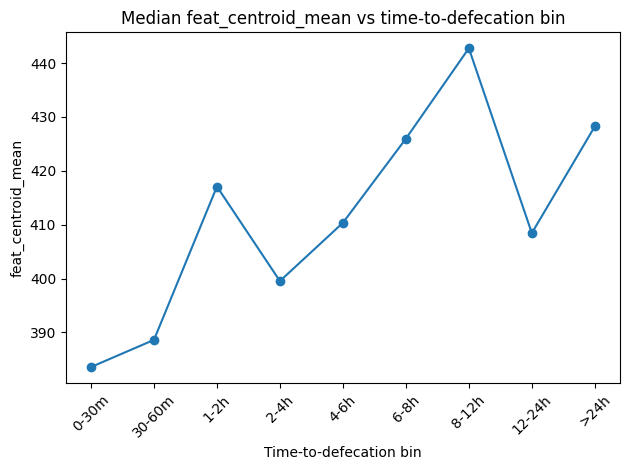

/tmp/ipython-input-1073295685.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data.groupby("t2d_bin")[c].median()


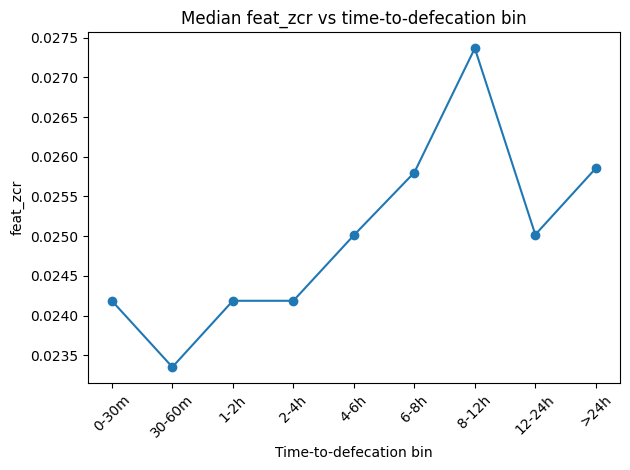

/tmp/ipython-input-1073295685.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data.groupby("t2d_bin")[c].median()


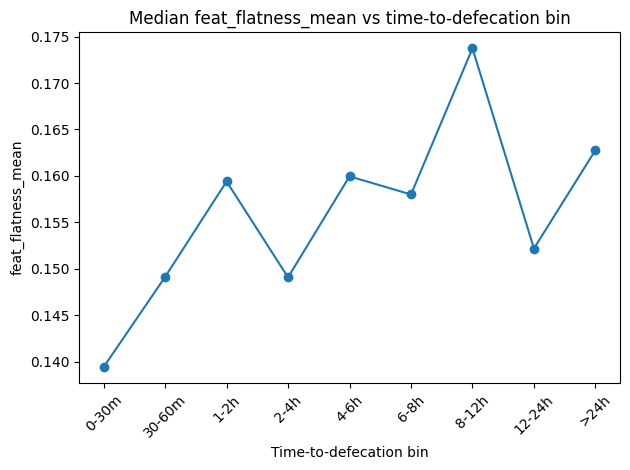

/tmp/ipython-input-1073295685.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data.groupby("t2d_bin")[c].median()


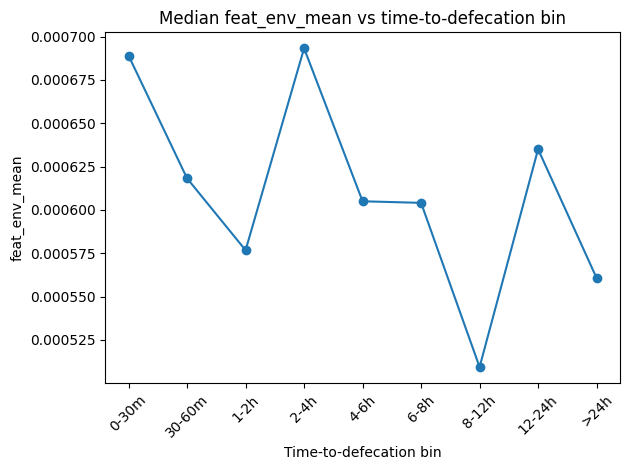

In [ ]:
bins = [0, 30, 60, 120, 240, 360, 480, 720, 1440, 999999]
labels = ["0-30m","30-60m","1-2h","2-4h","4-6h","6-8h","8-12h","12-24h",">24h"]
data["t2d_bin"] = pd.cut(data["minutes_until_defecation"], bins=bins, labels=labels, include_lowest=True)

top_feats = corr_df.head(4)["feature"].tolist() if len(corr_df) else feature_cols[:4]

for c in top_feats:
    grp = data.groupby("t2d_bin")[c].median()
    plt.figure()
    grp.plot(kind="line", marker="o")
    plt.title(f"Median {c} vs time-to-defecation bin")
    plt.xlabel("Time-to-defecation bin")
    plt.ylabel(c)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Step 5.1: Create session-normalized (z-score) features

In [ ]:
data_norm = data.copy()

feature_cols = [c for c in data.columns if c.startswith("feat_")]

BASELINE_MIN = 480  # 8 hours before defecation

for feat in feature_cols:
    z_col = feat + "_z"
    data_norm[z_col] = np.nan

    for sid, g in data.groupby("session_id"):
        baseline = g[g["minutes_until_defecation"] >= BASELINE_MIN][feat]

        # need enough baseline samples
        if len(baseline) < 20:
            continue

        mu = baseline.mean()
        sd = baseline.std()

        if sd == 0 or np.isnan(sd):
            continue

        idx = data_norm["session_id"] == sid
        data_norm.loc[idx, z_col] = (data_norm.loc[idx, feat] - mu) / sd


Step 5.2: Bin time-to-defecation--Gradual vs sudden vs none

In [ ]:
bins = [0, 30, 60, 120, 240, 360, 480, 720, 1440, 999999]
labels = ["0-30m","30-60m","1-2h","2-4h","4-6h","6-8h","8-12h","12-24h",">24h"]

data_norm["t2d_bin"] = pd.cut(
    data_norm["minutes_until_defecation"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


Step 5.3: Plot normalized evolution

/tmp/ipython-input-1317716789.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data_norm.groupby("t2d_bin")[c].median()


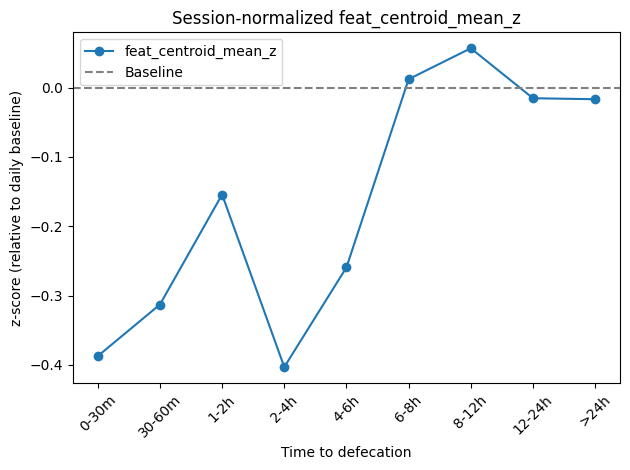

/tmp/ipython-input-1317716789.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data_norm.groupby("t2d_bin")[c].median()


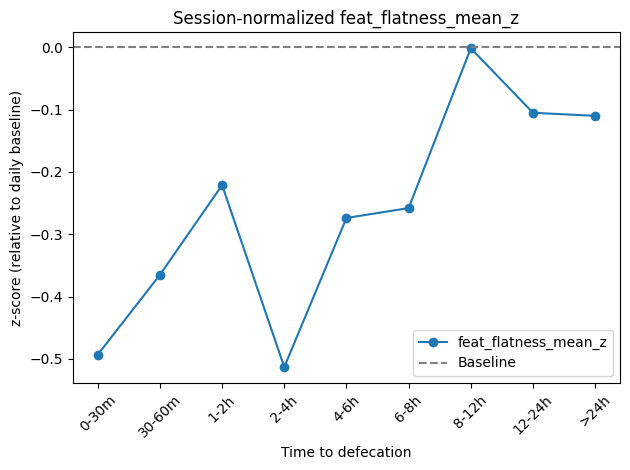

/tmp/ipython-input-1317716789.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = data_norm.groupby("t2d_bin")[c].median()


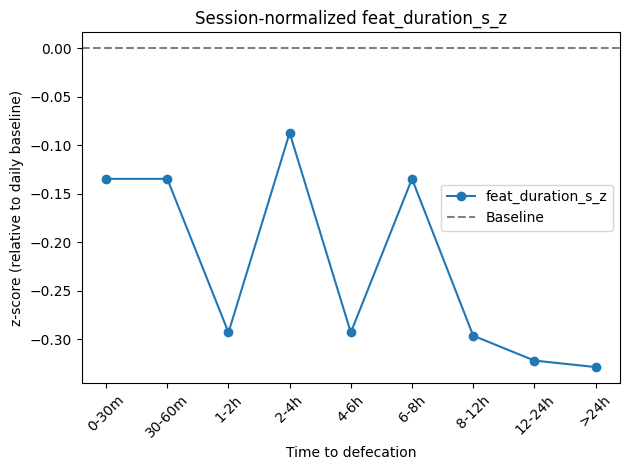

In [ ]:
important_feats = [
    "feat_centroid_mean_z",
    "feat_flatness_mean_z",
    "feat_duration_s_z"
]

for c in important_feats:
    grp = data_norm.groupby("t2d_bin")[c].median()

    plt.figure()
    grp.plot(marker="o")
    plt.axhline(0, linestyle="--", color="gray", label="Baseline")
    plt.title(f"Session-normalized {c}")
    plt.xlabel("Time to defecation")
    plt.ylabel("z-score (relative to daily baseline)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
